# CS1 — Gulf of Riga coastal upwelling, July 2021

Companion notebook for the *Computers & Geosciences* paper *An Open Python Framework for Reproducible Multi-Source Ocean Data Integration*. It loads the Zarr output produced by the offline fixture pipeline (`tests/fixtures/cs1_gulf_of_riga_offline.yaml`) and reproduces the figures used in the Results section.

**Reproducibility contract.** Re-running this notebook from a fresh checkout regenerates the identical content hash printed in the final section. The pipeline is declarative (YAML) and the data sources are deterministic Gulf-of-Riga-shaped fixtures that ship with the repository, so no external credentials are required.

## 1. Bootstrap — run the pipeline if its output is missing

In [51]:
from __future__ import annotations

import json
import os
from pathlib import Path

# Resolve the repository root regardless of where the notebook is launched.
NB_DIR = Path.cwd()
if NB_DIR.name == 'notebooks':
    REPO_ROOT = NB_DIR.parent
else:
    REPO_ROOT = NB_DIR
os.chdir(REPO_ROOT)

PIPELINE = Path('tests/fixtures/cs1_gulf_of_riga_offline.yaml')
OUTPUT   = Path('out/cs1_gulf_of_riga_upwelling_offline.zarr')
SIDECAR  = OUTPUT.with_suffix(OUTPUT.suffix + '.stac.json')

if not OUTPUT.exists():
    # Build synthetic fixtures (deterministic) and run the pipeline.
    from tests.fixtures.build_cs1_gulf_of_riga_fixtures import build_all
    build_all(REPO_ROOT / 'tests' / 'fixtures' / 'cs1_gulf_of_riga')
    import mosaic as ms
    ms.run(str(PIPELINE))

print(f'output: {OUTPUT} ({OUTPUT.exists()})')
print(f'sidecar: {SIDECAR} ({SIDECAR.exists()})')

output: out\cs1_gulf_of_riga_upwelling_offline.zarr (True)
sidecar: out\cs1_gulf_of_riga_upwelling_offline.zarr.stac.json (True)


## 2. Load the integrated dataset and its provenance sidecar

In [52]:
import xarray as xr

ds = xr.open_zarr(OUTPUT, consolidated=True)
with open(SIDECAR) as fh:
    stac = json.load(fh)

print(ds)

<xarray.Dataset> Size: 6MB
Dimensions:                                          (time: 11, latitude: 84,
                                                      longitude: 147)
Coordinates:
  * time                                             (time) datetime64[ns] 88B ...
  * latitude                                         (latitude) float32 336B ...
  * longitude                                        (longitude) float32 588B ...
    number                                           int64 8B ...
Data variables:
    eastward_wind                                    (time, latitude, longitude) float32 543kB ...
    eastward_wind_qc                                 (time, latitude, longitude) int8 136kB ...
    northward_wind                                   (time, latitude, longitude) float32 543kB ...
    northward_wind_qc                                (time, latitude, longitude) int8 136kB ...
    sea_surface_temperature                          (time, latitude, longitude) float64 1MB .

In [53]:
props = stac['properties']
summary = {
    'pipeline_hash': props['mosaic:pipeline_hash'],
    'content_hash':  props['mosaic:content_hash'],
    'sources':       [s['source_id'] for s in props['mosaic:inputs']],
    'mapping_accuracy': props['mosaic:harmonization']['mapping_accuracy'],
    'derived_variables': props['mosaic:harmonization']['derived']['derived'],
}
summary

{'pipeline_hash': 'blake3:fe957098148efed61a373b0672027288dd1e91b0677170963106536e4761f02b',
 'content_hash': 'blake3:fe5df7d7cd50687d3203b4990c569dcbc7c624fc4b8fc98ae17435d432d5aed4',
 'sources': ['cmems_sst', 'era5_wind'],
 'mapping_accuracy': 1.0,
 'derived_variables': ['wind_speed',
  'sst_spatial_anomaly',
  'upwelling_mask_sst',
  'upwelling_mask_sst_wind']}

## 3. SST evolution

Four-panel snapshot of `sea_surface_temperature` showing the thermal structure in the Gulf of Riga over 12--22 July 2021, providing context for the cold-water feature detected on 16 July.

In [54]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'figure.dpi': 110, 'font.size': 9})

def _panel_days(ds, n_panels=4):
    n = ds.sizes['time']
    return np.linspace(0, n - 1, n_panels, dtype=int)

panel_days = _panel_days(ds)
panel_days

array([ 0,  3,  6, 10])

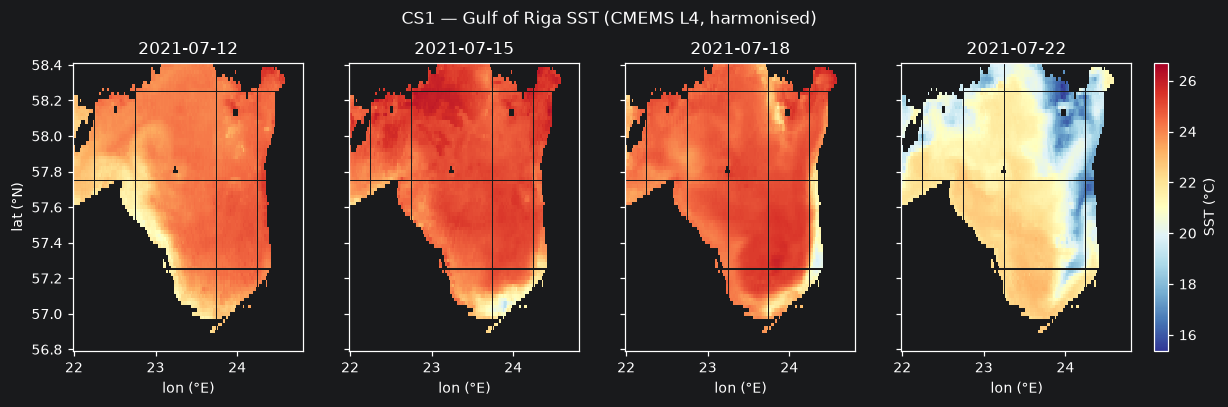

In [55]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharey=True)
sst_c = ds['sea_surface_temperature'] - 273.15
vmin, vmax = float(sst_c.min()), float(sst_c.max())
for ax, t_idx in zip(axes, panel_days):
    sst = sst_c.isel(time=t_idx)
    pcm = ax.pcolormesh(
        sst.longitude, sst.latitude, sst.values,
        cmap='RdYlBu_r', vmin=vmin, vmax=vmax, shading='auto',
    )
    ax.set_title(str(ds['time'].isel(time=t_idx).values)[:10])
    ax.set_xlabel('lon (°E)')
axes[0].set_ylabel('lat (°N)')
fig.colorbar(pcm, ax=axes, fraction=0.025, pad=0.02, label='SST (°C)')
fig.suptitle('CS1 — Gulf of Riga SST (CMEMS L4, harmonised)', y=1.02)
plt.show()

## 4. Spatial SST anomaly

`sst_spatial_anomaly = sea_surface_temperature − sea_surface_temperature_daily_spatial_median` is added in the *fuse* step. Negative values identify parts of the Gulf that are anomalously cold relative to the basin-scale daily median.

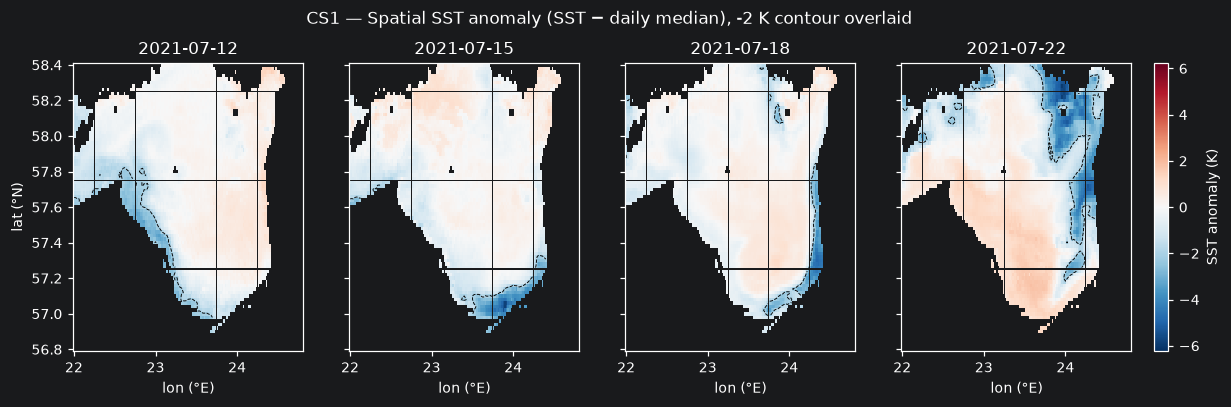

In [56]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharey=True)
ano_max = float(np.abs(ds['sst_spatial_anomaly']).max())
for ax, t_idx in zip(axes, panel_days):
    ano = ds['sst_spatial_anomaly'].isel(time=t_idx)
    pcm = ax.pcolormesh(
        ano.longitude, ano.latitude, ano.values,
        cmap='RdBu_r', vmin=-ano_max, vmax=ano_max, shading='auto',
    )
    ax.contour(
        ano.longitude, ano.latitude, ano.values,
        levels=[-2.0], colors='k', linewidths=0.6,
    )
    ax.set_title(str(ds['time'].isel(time=t_idx).values)[:10])
    ax.set_xlabel('lon (°E)')
axes[0].set_ylabel('lat (°N)')
fig.colorbar(pcm, ax=axes, fraction=0.025, pad=0.02, label='SST anomaly (K)')
fig.suptitle('CS1 — Spatial SST anomaly (SST − daily median), -2 K contour overlaid', y=1.02)
plt.show()

## 5. Wind regime

ERA5 10 m winds (`eastward_wind`, `northward_wind`) overlaid on the SST field for 16 July 2021. The pipeline derives `wind_speed` from the components, used in the downstream pixel-wise SST--wind intersection mask.

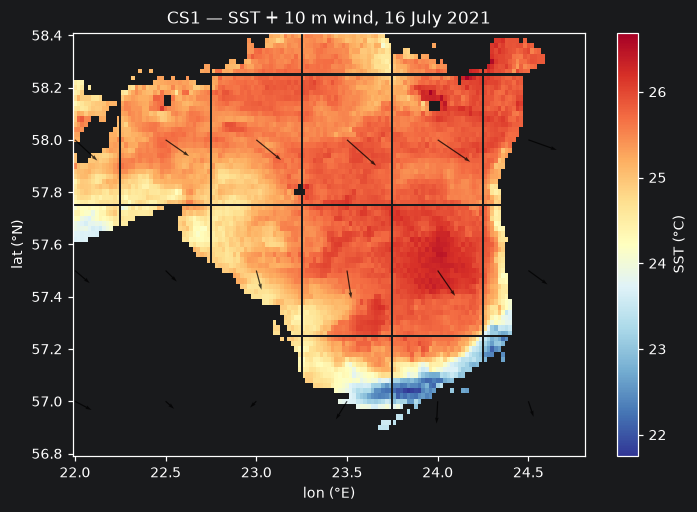

In [57]:
import pandas as pd
t16_idx = int(np.argmin(np.abs(
    pd.to_datetime(ds['time'].values) - pd.Timestamp('2021-07-16')
)))

step = 2
u = ds['eastward_wind'].isel(time=t16_idx)
v = ds['northward_wind'].isel(time=t16_idx)
sst_day = ds['sea_surface_temperature'].isel(time=t16_idx) - 273.15

fig, ax = plt.subplots(figsize=(7.5, 5.0))
pcm = ax.pcolormesh(
    sst_day.longitude, sst_day.latitude, sst_day.values,
    cmap='RdYlBu_r', shading='auto',
)
ax.quiver(
    u.longitude[::step], u.latitude[::step],
    u.values[::step, ::step], v.values[::step, ::step],
    scale=40, color='k', alpha=0.75,
)
ax.set_title('CS1 — SST + 10 m wind, 16 July 2021')
ax.set_xlabel('lon (°E)')
ax.set_ylabel('lat (°N)')
fig.colorbar(pcm, ax=ax, label='SST (°C)')
plt.show()

## 6. Upwelling masks

Two masks are derived:
- `upwelling_mask_sst` = `sst_spatial_anomaly < -2 K` (SST-only footprint)
- `upwelling_mask_sst_wind` = `(sst_spatial_anomaly < -2 K) & (wind_speed > 4 m s⁻¹)`
  (pixel-wise intersection — empty on 16 July 2021 in the live workflow)


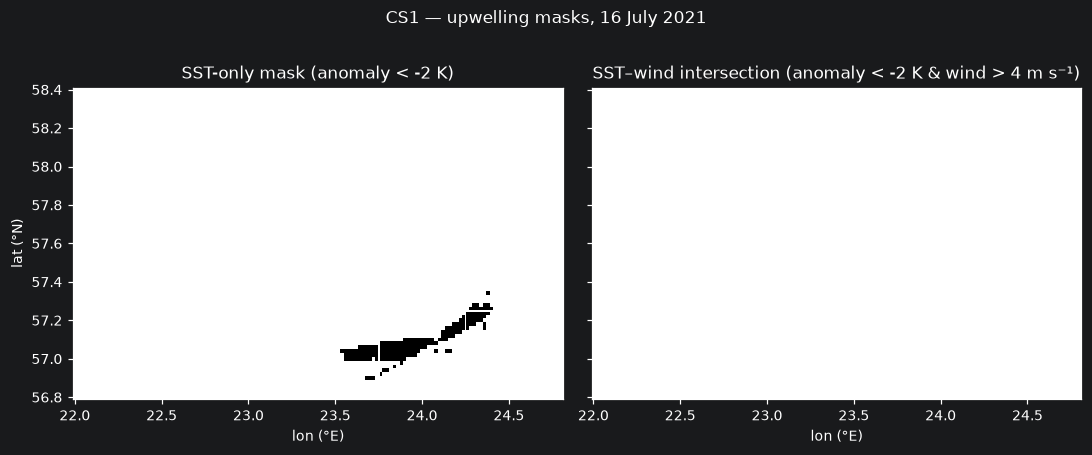

SST-only mask: 180 cells flagged
SST–wind mask: 0 cells flagged


In [58]:
mask_sst  = ds['upwelling_mask_sst'].isel(time=t16_idx).astype('uint8')
mask_both = ds['upwelling_mask_sst_wind'].isel(time=t16_idx).astype('uint8')

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, m, title in zip(
    axes,
    [mask_sst, mask_both],
    ['SST-only mask (anomaly < -2 K)',
     'SST–wind intersection (anomaly < -2 K & wind > 4 m s⁻¹)'],
):
    ax.pcolormesh(m.longitude, m.latitude, m.values, cmap='Greys', vmin=0, vmax=1, shading='auto')
    ax.set_title(title)
    ax.set_xlabel('lon (°E)')
axes[0].set_ylabel('lat (°N)')
fig.suptitle('CS1 — upwelling masks, 16 July 2021', y=1.02)
plt.tight_layout()
plt.show()

print(f'SST-only mask: {int(mask_sst.sum().values)} cells flagged')
print(f'SST–wind mask: {int(mask_both.sum().values)} cells flagged')

## 7. Temporal evolution of flagged cells

Daily counts of grid cells satisfying each mask over the full CS1 window. This summarises the difference between the spatial SST footprint and the more restrictive local SST--wind overlap.

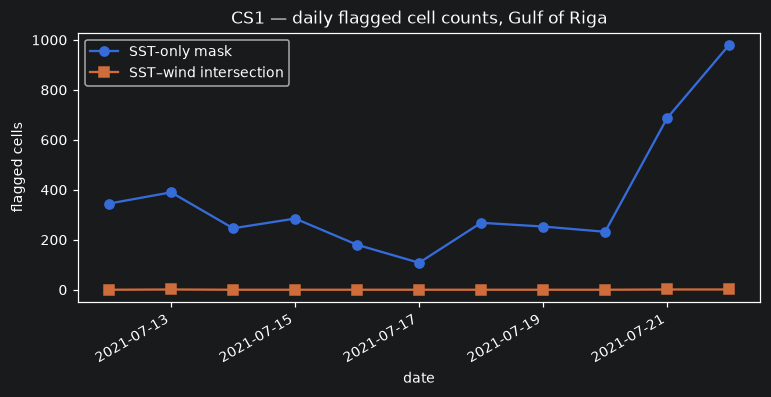

In [59]:
sst_counts  = ds['upwelling_mask_sst'].astype('uint8').sum(dim=('latitude', 'longitude')).values
wind_counts = ds['upwelling_mask_sst_wind'].astype('uint8').sum(dim=('latitude', 'longitude')).values
times = ds['time'].values

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(times, sst_counts,  marker='o', label='SST-only mask')
ax.plot(times, wind_counts, marker='s', label='SST–wind intersection')
ax.set_ylabel('flagged cells')
ax.set_xlabel('date')
ax.set_title('CS1 — daily flagged cell counts, Gulf of Riga')
ax.legend()
fig.autofmt_xdate()
plt.show()

## 8. Provenance — content addressing of the result

Every MOSAIC run emits a STAC sidecar that pins the exact pipeline and the bit-exact output. The hashes below should match across machines and Python versions when the fixture-based pipeline is used.

In [60]:
for k in ('mosaic:pipeline_hash', 'mosaic:content_hash'):
    print(f'{k:<25} {props[k]}')

print()
print('inputs:')
for inp in props['mosaic:inputs']:
    print(f"  - {inp['source_id']:<10} {inp['plugin']:<14} {inp.get('uri', '')}")

print()
print('derived:')
for d in props['mosaic:harmonization']['derived']['derived']:
    print(f'  + {d}')

mosaic:pipeline_hash      blake3:fe957098148efed61a373b0672027288dd1e91b0677170963106536e4761f02b
mosaic:content_hash       blake3:fe5df7d7cd50687d3203b4990c569dcbc7c624fc4b8fc98ae17435d432d5aed4

inputs:
  - cmems_sst  local_netcdf   
  - era5_wind  local_netcdf   

derived:
  + wind_speed
  + sst_spatial_anomaly
  + upwelling_mask_sst
  + upwelling_mask_sst_wind


---
*Notebook generated by `notebooks/_build_cs1_notebook.py`. Do not edit by hand — regenerate from the script to keep the build auditable.*